In [2]:
# adapted from https://github.com/DifferentiableUniverseInitiative/Baryonator/blob/main/notebooks/EGD_demo_on_CAMELS.ipynb

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'

import numpy as np
import matplotlib.pyplot as plt
import h5py
from tqdm import tqdm

import jax
import jax.lax as lax 
import jax.numpy as jnp
import optax

from jaxpm import camels, objectives, egd
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, gaussian_kernel

/global/common/software/des/athomsen/flatiron/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


# Loading the CAMELS snapshot

In [5]:
# reference in Francois' notebook
# CV = "CV_0"
# CODE = "IllustrisTNG"
# mesh_shape = [128] * 3
# parts_per_dim = None

In [6]:
i_snapshot = -1

# mesh_shape = [64] * 3
mesh_shape = [128] * 3
# mesh_shape = [256] * 3

parts_per_dim = mesh_shape[0]
# parts_per_dim = None

# CODE = "IllustrisTNG"
CODE = "SIMBA"

CV = "CV_0"
# CV = "CV_1"


CAMELS = "/pscratch/sd/a/athomsen/flatiron/CAMELS"

dmo_dict = camels.load_CV_snapshots(
    CV,
    mesh_shape[0],
    parts_per_dim=parts_per_dim,
    i_snapshots=i_snapshot,
    CAMELS=CAMELS,
    CODE=CODE,
    return_hydro=False,
)

hydro_dict = camels.load_CV_snapshots(
    CV,
    mesh_shape[0],
    parts_per_dim=parts_per_dim,
    i_snapshots=i_snapshot,
    CAMELS=CAMELS,
    CODE=CODE,
    return_hydro=True,
)

Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA_DM/CV/CV_0/parts=128,mesh=128,i=[-1].h5
Loaded /pscratch/sd/a/athomsen/flatiron/CAMELS/h5/SIMBA/CV/CV_0/parts=128,mesh=128,i=[-1].h5


In [7]:
p_spectrum = lambda delta: power_spectrum(
    compensate_cic(delta),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

x_spectrum = lambda delta_1, delta_2: cross_correlation_coefficients(
    compensate_cic(delta_1),
    compensate_cic(delta_2),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

In [8]:
dmo_pos_dm = dmo_dict["dm_poss"]
hydro_pos_dm = hydro_dict["dm_poss"]
hydro_pos_gas = hydro_dict["gas_poss"]

cosmo = hydro_dict["cosmo"]
Omega_m = cosmo.Omega_m
Omega_b = cosmo.Omega_b

dm_mass = cosmo.Omega_c / (cosmo.Omega_b + cosmo.Omega_c)
gas_mass = 1 - dm_mass

[Text(0.5, 1.0, 'Hydro Gas')]

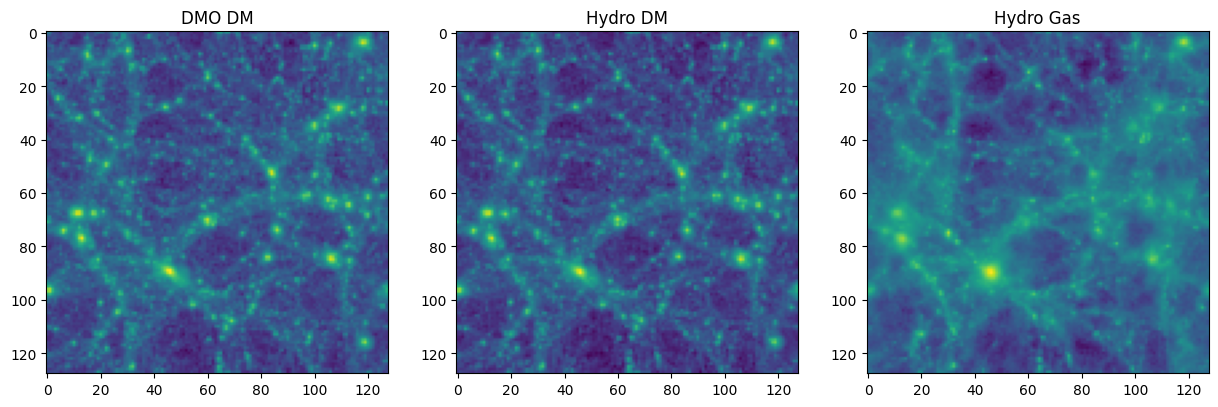

In [9]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

ax[0].imshow(cic_paint(jnp.zeros(mesh_shape), dmo_pos_dm).sum(axis=0), norm="log")
ax[0].set(title="DMO DM")

ax[1].imshow(cic_paint(jnp.zeros(mesh_shape), hydro_pos_dm).sum(axis=0), norm="log")
ax[1].set(title="Hydro DM")

ax[2].imshow(cic_paint(jnp.zeros(mesh_shape), hydro_pos_gas).sum(axis=0), norm="log")
ax[2].set(title="Hydro Gas")

## Comparing the two simulations

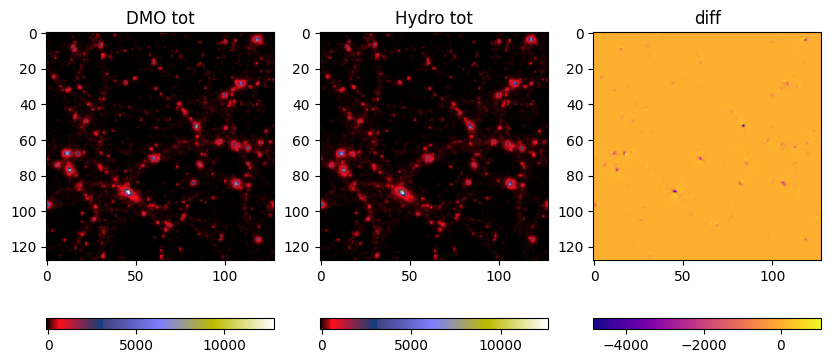

In [25]:
# On the DMO side, we only grab the dark matter
tot_rho_dmo = cic_paint(jnp.zeros(mesh_shape), dmo_pos_dm, weight=1)
tot_delta_dmo = tot_rho_dmo / tot_rho_dmo.mean() - 1

# On the hydro side, let's add both DM and baryons
dm_rho_hydro = cic_paint(jnp.zeros(mesh_shape), hydro_pos_dm, weight=dm_mass)
gas_rho_hydro = cic_paint(jnp.zeros(mesh_shape), hydro_pos_gas, weight=gas_mass)
tot_rho_hydro = dm_rho_hydro + gas_rho_hydro

gas_delta_hydro = gas_rho_hydro / gas_rho_hydro.mean() - 1
tot_delta_hydro = tot_rho_hydro / tot_rho_hydro.mean() - 1

fig, ax = plt.subplots(ncols=3, figsize=(10,5))

im = ax[0].imshow(tot_delta_dmo.sum(axis=0), cmap="gist_stern")
ax[0].set(title="DMO tot")
fig.colorbar(im, ax=ax[0], orientation="horizontal")

im = ax[1].imshow(tot_delta_hydro.sum(axis=0), cmap="gist_stern")
ax[1].set(title="Hydro tot")
fig.colorbar(im, ax=ax[1], orientation="horizontal")

im = ax[2].imshow((tot_delta_hydro - tot_delta_dmo).sum(axis=0), cmap="plasma")
ax[2].set(title="diff")
fig.colorbar(im, ax=ax[2], orientation="horizontal")

In [26]:
# Let's compute the power spectra
k, pk_hydro = p_spectrum(tot_delta_hydro)
_, pk_dmo = p_spectrum(tot_delta_dmo)
_, xpk = x_spectrum(tot_delta_hydro, tot_delta_dmo)

[None,
 None,
 Text(0.5, 0, '$k$ [$h \\ \\mathrm{Mpc}^{-1}$]'),
 Text(0, 0.5, '$P(k)$')]

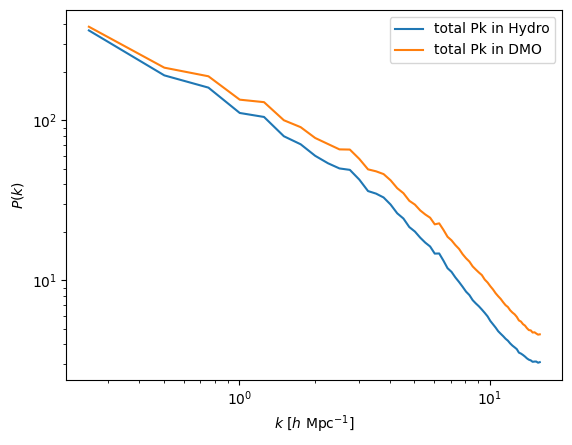

In [27]:
fig, ax = plt.subplots()

ax.plot(k, pk_hydro, label='total Pk in Hydro')
ax.plot(k, pk_dmo, label='total Pk in DMO')
ax.legend()
ax.set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")

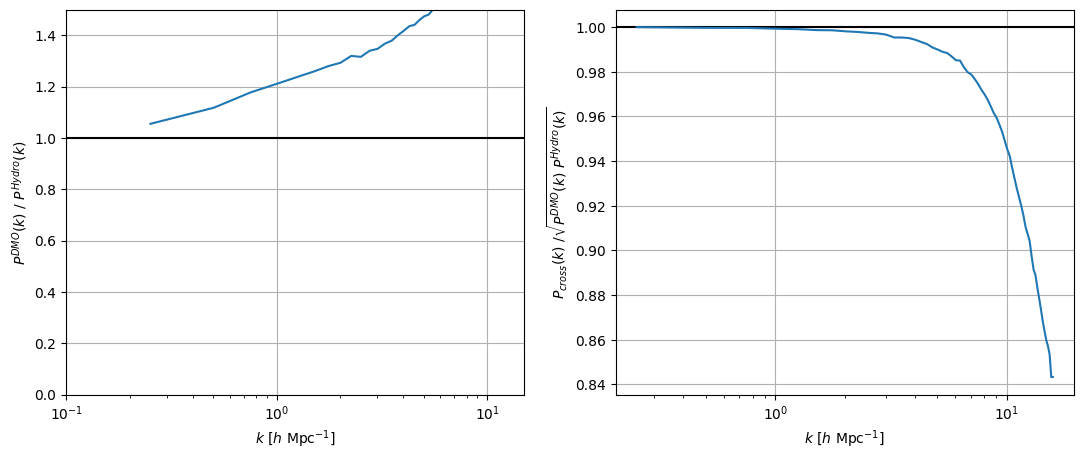

In [28]:
fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_dmo/pk_hydro))   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[0].grid(True)

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk/(jnp.sqrt(pk_dmo * pk_hydro)))
ax[1].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    # xlim=(0.1, 15),
    # ylim=(0.5, 1.05),
)
ax[1].grid()

## Implementing vanilla Enthalpy Gradient Descent

Here we first attempt to reproduce the results of [Dai et al. 2018](https://arxiv.org/abs/1804.00671) which introduces a method coined EGD to displace DM particles in a DMO run into tracing the total matter distribution from a full hydro run.

In this work, the authors assume that a fraction $\Omega_b/\Omega_m$ of the particles will be displaced according to this EGD prescription. We are thus going to split our input DM particles into 2 populations, randomly.

In [36]:
inds = jax.random.permutation(jax.random.PRNGKey(42), jnp.arange(0,len(dmo_pos_dm)-1))
split = int(Omega_b/Omega_m*len(dmo_pos_dm))
egd_pos_gas = dmo_pos_dm[inds[:split]]
egd_pos_dm  = dmo_pos_dm[inds[split:]]

egd_rho_dm = cic_paint(jnp.zeros(mesh_shape), egd_pos_dm)

Now let's try to optimize parameters of this model

In [61]:
total_steps = 10_000
# learning_rate = 1e-1
# optimizer = optax.adam(learning_rate)

learning_rate = optax.cosine_decay_schedule(
    init_value=1e-2,
    decay_steps=total_steps, 
    alpha=0.0,
)
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(learning_rate)
)

In [62]:
_, pk_hydro_tot = p_spectrum(tot_delta_hydro)
_, pk_hydro_gas = p_spectrum(gas_delta_hydro)

# I define my loss function
@jax.jit
def loss_fn(params):
    egdized_pos_gas = egd_pos_gas + egd.egd_correction(params, tot_delta_dmo, egd_pos_gas, mesh_shape)
    
    # Add the gas that we have moved to the dm that stayed where it was
    egd_rho_gas = cic_paint(jnp.zeros(mesh_shape), egdized_pos_gas)
    egd_rho_tot = egd_rho_dm + egd_rho_gas

    delta_gas = egd_rho_gas / egd_rho_gas.mean() - 1
    k, pk_gas = p_spectrum(delta_gas)
    inds = k < 3.0
    loss = jnp.sum(((pk_gas/pk_hydro_gas - 1))[inds]**2, axis=-1)

    return loss
    
    # delta_tot = egd_rho_tot / egd_rho_tot.mean() - 1
    
    # # Compute the PS of everybody
    # k, pk = p_spectrum(delta_tot)
    
    # # Some weighting function of the pk, following Biwei's strategy
    # inds = k < 10.
    # loss = jnp.sum(((pk/pk_hydro -1))[inds]**2,axis=-1)
    
    # # loss = jnp.sum((delta-tot_delta_hydro)**2)
    
    # return loss



In [63]:
# wrappers fixing the global variables within the notebook

# @jax.jit
# def loss_fn(params):

@jax.jit
def update(params, opt_state):
    return egd.update(params, optimizer, opt_state, loss_fn)

In [64]:
# Let's initialize parameters and optimizer
params = [0.5, 1.4, 0.4] # amplitude, scale, gamma
opt_state = optimizer.init(params)
losses = []

100%|██████████| 10000/10000 [00:56<00:00, 178.56it/s]


[Array(0.00071771, dtype=float32), Array(0.47892365, dtype=float32), Array(1.863599, dtype=float32)]


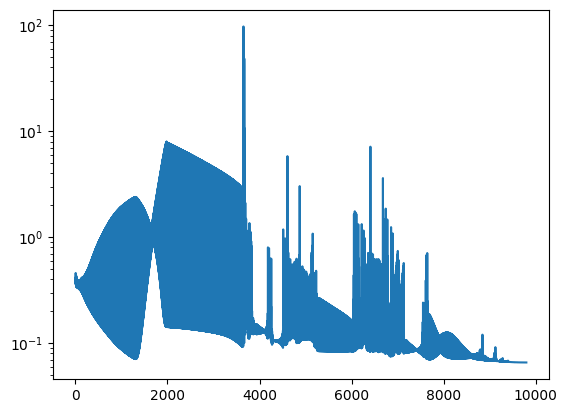

In [65]:
for step in tqdm(range(total_steps)):
  l, params, opt_state = update(params, opt_state)
  losses.append(l)

fig, ax = plt.subplots()
ax.plot(losses[200:])
ax.set(yscale="log")
print(params)

In [66]:
# params = [
#     np.array(0.5484464, dtype=np.float32),

#     np.array(7.750823, dtype=np.float32),
#     np.array(0.29083464, dtype=np.float32)
# ]

In [67]:
# params = [
#     np.array(0.79741, dtype=np.float32),
#     np.array(7.9030437, dtype=np.float32),
#     np.array(0.51323, dtype=np.float32)
# ]

In [68]:
# # SIMBA 128^3
# params = [
#     np.array(0.01180707, dtype=np.float32),
#     np.array(8.127216, dtype=np.float32),
#     np.array(1.0366087, dtype=np.float32),
# ]

In [69]:
# Let's look at the result
# On the DMO side, we only grab the dark matter
gas_rho_egd = cic_paint(jnp.zeros(mesh_shape), egd_pos_gas + egd.egd_correction(params, tot_delta_dmo, egd_pos_gas, mesh_shape))
tot_rho_egd = egd_rho_dm + gas_rho_egd
tot_delta_egd = tot_rho_egd/tot_rho_egd.mean() - 1

[Text(0.5, 1.0, 'DMO+EGD tot')]

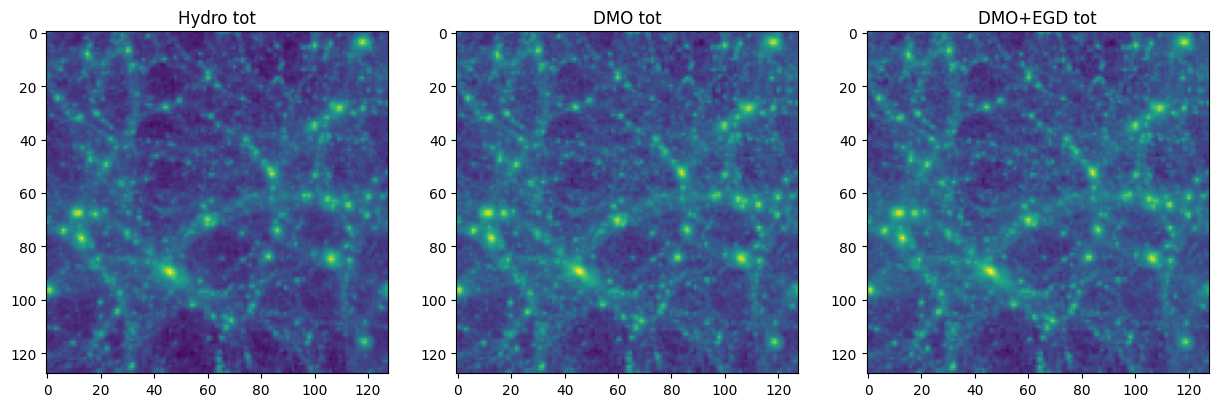

In [70]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

ax[0].imshow(tot_rho_hydro.sum(axis=0), norm="log")
ax[0].set(title="Hydro tot")

ax[1].imshow(tot_rho_dmo.sum(axis=0), norm="log")
ax[1].set(title="DMO tot")

ax[2].imshow(tot_rho_egd.sum(axis=0), norm="log")
ax[2].set(title="DMO+EGD tot")

[Text(0.5, 1.0, 'EGD Gas')]

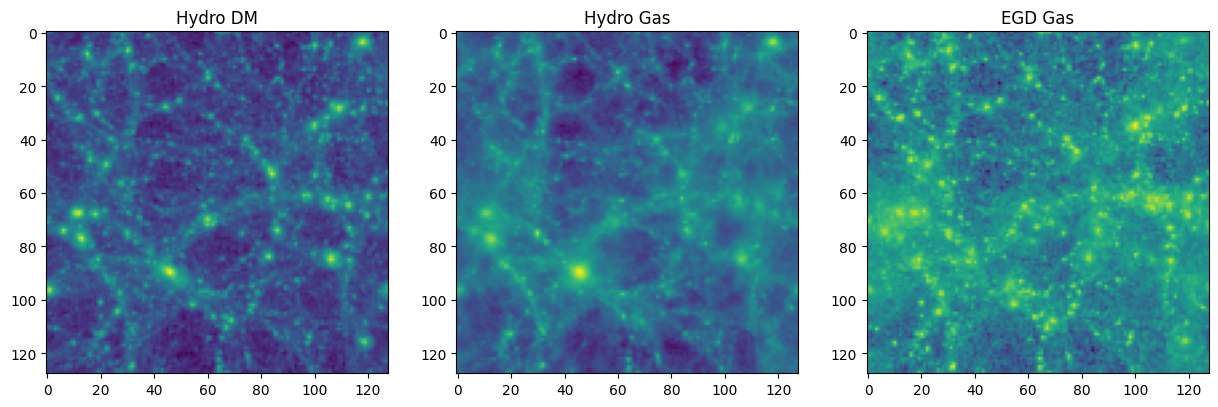

In [71]:
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

ax[0].imshow(dm_rho_hydro.sum(axis=0), norm="log")
ax[0].set(title="Hydro DM")

ax[1].imshow(gas_rho_hydro.sum(axis=0), norm="log")
ax[1].set(title="Hydro Gas")

ax[2].imshow(
    cic_paint(
        jnp.zeros(mesh_shape), 
        egd_pos_gas + egd.egd_correction(params, tot_delta_dmo, egd_pos_gas, mesh_shape)
    ).sum(axis=0), 
    norm="log"
)
ax[2].set(title="EGD Gas")

[Text(0.5, 1.0, 'EGD Gas')]

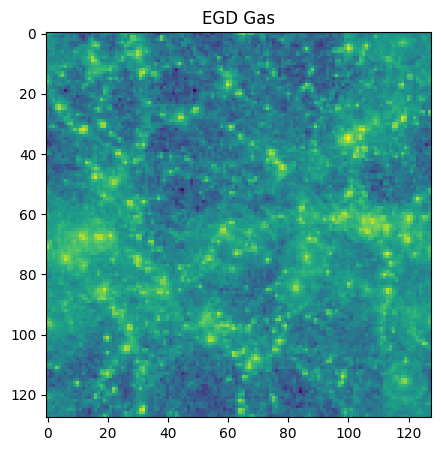

In [72]:
fig, ax = plt.subplots(figsize=(15,5))

ax.imshow(
    cic_paint(
        jnp.zeros(mesh_shape), 
        egd_pos_gas + egd.egd_correction(params, tot_delta_dmo, egd_pos_gas, mesh_shape)
    ).sum(axis=0), 
    norm="log",
)
ax.set(title="EGD Gas")

In [73]:
# fig, ax = plt.subplots(ncols=3, figsize=(15,5))

# ax[0].imshow(tot_delta_hydro.sum(axis=0), cmap='gist_stern')
# ax[0].set(title="Hydro")

# ax[1].imshow(tot_delta_dmo.sum(axis=0), cmap='gist_stern')
# ax[1].set(title="DMO")

# ax[2].imshow(tot_delta_egd.sum(axis=0), cmap='gist_stern')
# ax[2].set(title="DMO+EGD")

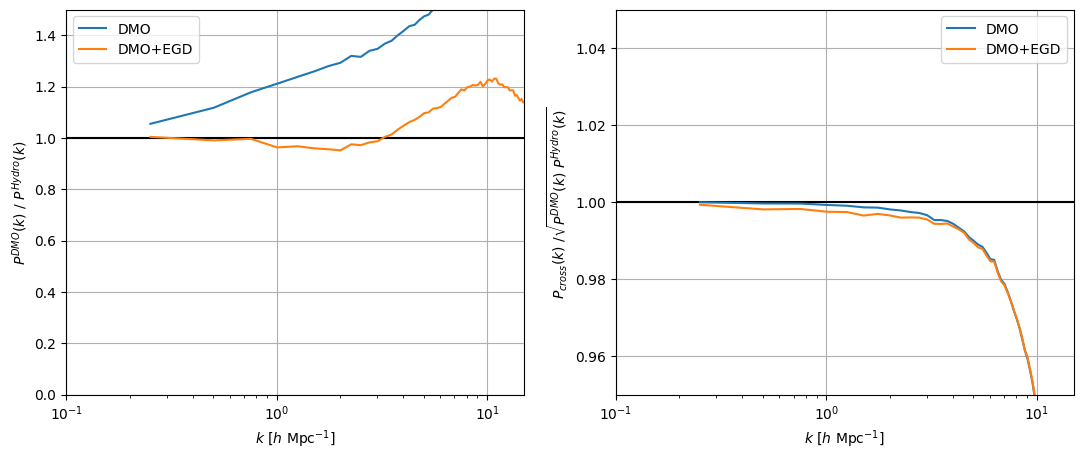

In [74]:
# Now let's compute 2pt stats
_, pk_egd = power_spectrum(
      compensate_cic(tot_delta_egd),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

_, xpk_egd = cross_correlation_coefficients(compensate_cic(tot_delta_hydro), compensate_cic(tot_delta_egd),
      boxsize=np.array([25.] * 3),
      kmin=np.pi / 25.,
      dk=2 * np.pi / 25.)

fig, ax = plt.subplots(figsize=[13,5], ncols=2)

ax[0].axhline(1., color='black')
ax[0].semilogx(k, (pk_dmo/pk_hydro), label='DMO')   
ax[0].semilogx(k, (pk_egd/pk_hydro), label='DMO+EGD')   
ax[0].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P^{DMO}(k) \ / \ P^{Hydro}(k)$",
    xlim=(0.1, 15),
    ylim=(0., 1.5),
)
ax[0].grid(True)
ax[0].legend()

ax[1].axhline(1., color='black')
ax[1].semilogx(k, xpk/(jnp.sqrt(pk_dmo)*jnp.sqrt(pk_hydro)), label='DMO')
ax[1].semilogx(k, xpk_egd/(jnp.sqrt(pk_egd)*jnp.sqrt(pk_hydro)), label='DMO+EGD')
ax[1].set(
    xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", 
    ylabel=r"$ P_{cross}(k) \ / \sqrt{ P^{DMO}(k) \ P^{Hydro}(k)}$",
    xlim=(0.1, 15),
    ylim=(0.95, 1.05),
)
ax[1].grid()
ax[1].legend()

# trash

In [29]:
stop

NameError: name 'stop' is not defined

In [ ]:
egdized_pos_gas = egd_pos_gas + egd_correction(tot_delta_dmo, egd_pos_gas, params)
delta_egd_gas = cic_paint(jnp.zeros(mesh_shape), egdized_pos_gas)
delta_egd_gas = delta_egd_gas/delta_egd_gas.mean() - 1.

# Compute the PS of everybody
k, pk_egd_gas = power_spectrum(
    compensate_cic(delta_egd_gas),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)

delta_gas = cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"])
delta_gas = delta_gas/delta_gas.mean() - 1.

# Compute the PS of everybody
k, pk_gas = power_spectrum(
    compensate_cic(delta_gas),
    boxsize=np.array([25.] * 3),
    kmin=np.pi / 25.,
    dk=2 * np.pi / 25.
)


In [ ]:
fig, ax = plt.subplots()

ax.plot(k, pk_gas, label='gas Pk in Hydro')
ax.plot(k, pk_egd_gas, label='gas Pk in DMO + EGD')
ax.legend()
ax.set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")